<a href="https://colab.research.google.com/github/AshtonMB/Data-and-the-State-Spring-Qtr-UChicago-Micro-Projects/blob/main/Data%26State_Micro_Project_Final_Ashton_Mayo_Beavers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Crime, Disorder, and Spatial Perceptions of Safety in Chicago (2021)**
### *Research Question: How do Index crimes, Non-Index crimes, and indicators of perceived disorder differ spatially across Chicago ?*

---
###Ashton Mayo-Beavers
###Data and the States - Spring 2026
###Graduate Level Final Micro Project





In [130]:
# @title
!pip install sodapy
!pip install contextily

import requests
import pandas as pd
from sodapy import Socrata
import matplotlib.pyplot as plt
import io
import geopandas as gpd
import plotly.express as px
import numpy as np
import contextily as cx

## **Datasets Used in this Micro Project**

1. Chicago Data Portal : Crimes - 2001 to Present [access data portal](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data )

2. Supplemental: Chicago-Police-Department-Illinois-Uniform-Crime Codes [access to data portal](https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/about_data)

3. Chicago Data Portal : 311 Service Requests [access data protal](https://data.cityofchicago.org/resource/v6vf-nfxy.json)

4. Supplemental: Chicago Data Portal - 311 Service Request - Request Types [access data portal](https://data.cityofchicago.org/Service-Requests/311-Service-Requests-Request-Types/dgc7-2pdf/about_data)

# **Literature Review**

## **The MAUP for Crime Data**

The choice of spatial units is very sensitive to crime data. Malleson et al. note in their paper "Identifying the appropriate spatial resolution for the analysis of crime patterns" (2019) that small spatial units can lead to colatinity, which skews regression analysis. Specifically, they note that while "recent research has found that crime concentrates at ‘micro places’ and, in general, a small unit of analysis is the most appropriate for many quantitative environmental criminology studies," (Malleson, N., Steenbeek, W., & Andresen, M. A., 2019), the "best spatial scale" for analyzing geographic crime patterns depends on the number of crime events, degree of spatial clustering, and density of incidents(Malleson, N., Steenbeek, W., & Andresen, M. A., 2019). The standardised criminological ideas hold that crime is concentrated in micro-places. Also, with a new method of scale analysis (Multi-Scale Error Analysis) , the Nearest Neighbor Index is proposed as a theoretical solution to evaluate spatial clustering of crime events and how tightly the incidents are grouped together geographically, which can help determine if the crime patterns being overseen are meaningful at smaller spatial *resolutions* or may require large spatial units (Malleson, N., Steenbeek, W., & Andresen, M. A., 2019). This is also essential to the crux of the research question: examining perception versus actual crime in a highly spatially segregated city, and how different spatial patterns of perceived crime (micro and macro) differ from actual crime patterns across Chicago and its community areas. Their research provides a foundational methodological framework for understanding how spatial patterns change by crime type, and how spatial scale is used to examine how different forms of crime perception and reporting produce different geographies and patterns of crime. Following Malleson et a.l (2019), this project recognized that spatial scale influences the interpretation of crime distributions. There areas are characterized by high geographic dispersion, whose community areas are socially meaningful yet internally heterogeneous and heavily segregated. While previous research has demonstrated that crime patterns vary substantially with spatial resolution, less attention has been paid to how perceived diverge spatially from officially reported crime. Using Chicago as a case study in 2021, this project will build on this paper to explore spatial patterns and relations of distinct geographic narratives or urban danger. For the scope of this project our micro spatial units are Chicago community areas that geo-code both the 311 dataset and the Crime data set (Malleson, N., Steenbeek, W., & Andresen, M. A., 2019).

---


References:

Malleson, N., Steenbeek, W., & Andresen, M. A. (2019). Identifying the appropriate spatial resolution for the analysis of crime patterns. PloS one, 14(6), e0218324. https://doi.org/10.1371/journal.pone.0218324

## **Crime vs. Fear of Crime: Data Context and Background**

According to the Illinois Criminal Justice Information Authority, the fear of crime is largely inflated by "factors beyond local crime rates" (Authority, I. C. J. I.,2017) that have seen rates of decrease. "True risk for victimization may be overestimated as a result of disproportionate concerns about violent crime and inaccurate assessments of crime" (Authority, I. C. J. I.,2017). They go on to cites this "fear of crime" -- which one of the measures that of mentioned for this is non-violent crimes including vandlaizm which is captures in the late ingested 311 data - as connected to Shaw and MaKays social disorgainzation theory where "fear of crime is viewed as both a consequence and cause of neighborhood disorganization" and feelings of vulnerabilty Authority, I. C. J. I.,2017). Interestingly enough, the theory of social disorganization developed by Clifford Shaw in 1929 with Henry McKay was developed out of a study, "Juvenile Delinquency and Urban Areas“ in Chicago, the area of focus for this project. A facet of this theory is that cultural transmission explains why people perceive a neighborhood as dangerous even when actual crime rates drop, due to the reputation of a place that outlives the behavior of its residents, even when crime rates drop (Social Disorganization Theory – Explaining Crime in Urban Neighborhoods | SozTheo, n.d.). This portion of the theory highlights that there is a disconnect between actual crime (the physical illegal acts) and the spatial perception (how safe a place feels based on its appearance and history) (Social Disorganization Theory – Explaining Crime in Urban Neighborhoods | SozTheo, 2018;2026).

This project uses officially reported crime data from the Chicago Police Department, categorized according to the Illinois Uniform Crime Reporting (IUCR) codes. The IUCR codes are four-digit codes with 400 different types divided into "Index" and "Non-Index" offences. For this scope, the primary comparison will focus on the spatial distribution of Index and Non-Index offences in Chicago during 2021. "Index" offences include serious violent and property crimes, including murder, criminal sexual assault, robbery, aggrevated assalt & battery, burglary, theft, motor vehicle theft, and arson. These types of crimes are traditionally used in crime statistics because they are considered major offences with substantial social and public safety impacts (Illinois State Police, n.d.).


Non-Index crimes include offences such as narcotics, vandalism, criminal trespass, public order violation, disorderly conduct, prostitution, and gambling. For the purposes of this project, these will be conceptually understood as crimes associated with perceptions of neighborhood disorder or quality-of-life concerns. The core argument is to determine if spatial patterns of Index crimes (serious offences) and Non-Index crimes (linked to perceptions of disorder) differ across neighborhoods, and how these differences might inform our understanding of urban safety perceptions versus actual reported crime in Chicago.

---

References:

Authority, I. C. J. I. (2017). ICJIA. Illinois Criminal Justice Information Authority. Retrieved May 28, 2026, from https://icjia.illinois.gov/

Illinois State Police. (n.d.). Illinois Uniform Crime Reporting Program: Monthly index crime form (ISP 2-423C). State of Illinois. https://isp.illinois.gov/StaticFiles/docs/CrimeReporting/2-423c.

Social Disorganization Theory – Explaining Crime in Urban Neighborhoods | SozTheo. (2018, 2026). Retrieved May 28, 2026, from https://soztheo.com/theories-of-crime/space-surveillance/soziale-desorganisation-shaw-mckay/




# **X. Chicago Crime Data**

The first data set to be used is the City of Chicago Crimes - 2001 to Present.The variables of interest are:

**id**: unique identifier for the record

**community_area** (String) :
Indicates the community area where the incident occurred. Chicago has 77 community areas.

**date** : Date when the incident occurred. this is sometimes a best estimate.

**block**: The partially redacted address where the incident occurred, placing it on the same block as the actual address.

**iucr**:
The Illinois Uniform Crime Reporting code. This is directly linked to the Primary Type and Description. See the list of IUCR codes

More about the codes can be found [here](https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/about_data).




In [3]:
'''
About Code Chunk: This code chunk injests the Crime data as a first look but this on gets the 2026 data.
A second api injestio is done later in the notebook with a conditional query base on year
'''

api_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

try:
    # Directly read the CSV data into a pandas DataFrame
    chicago_crime_df = pd.read_csv(api_url)

    print("Data loaded successfully. Here's the head of the DataFrame:")
    display(chicago_crime_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching data from API: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
chicago_crime_df["year"].unique()


Data loaded successfully. Here's the head of the DataFrame:


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14203052,JK261710,2026-05-20T00:00:00.000,011XX W EDDY ST,0320,ROBBERY,STRONG ARM - NO WEAPON,ALLEY,False,False,...,44,6,03,1168374.0,1923737.0,2026,2026-05-27T15:46:08.000,41.946268,-87.656511,"\n, \n(41.946268365, -87.656511314)"
1,14208681,JK268606,2026-05-20T00:00:00.000,031XX S PRAIRIE AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,4,35,07,1178469.0,1884165.0,2026,2026-05-27T15:46:08.000,41.837456,-87.620614,"\n, \n(41.837456197, -87.620613967)"
2,14203453,JK262138,2026-05-20T00:00:00.000,015XX S HOMAN AVE,0460,BATTERY,SIMPLE,ALLEY,True,False,...,24,29,08B,1153950.0,1892262.0,2026,2026-05-27T15:46:08.000,41.860198,-87.710370,"\n, \n(41.860198373, -87.710369536)"
3,14203308,JK262172,2026-05-20T00:00:00.000,028XX S STATE ST,1599,SEX OFFENSE,AGG CRIM SEX ABUSE - VIC 13-16 YOA - OFF 5 YR ...,APARTMENT,False,False,...,3,35,17,1176743.0,1886065.0,2026,2026-05-27T15:46:08.000,41.842709,-87.626890,"\n, \n(41.842709067, -87.626890005)"
4,14204555,JK263572,2026-05-20T00:00:00.000,018XX W ADAMS ST,0560,ASSAULT,SIMPLE,APARTMENT,False,False,...,27,28,08A,1164224.0,1899120.0,2026,2026-05-27T15:46:08.000,41.878807,-87.672463,"\n, \n(41.878806573, -87.672462521)"


array([2026])


# **XI. Illinois Uniform Crime Reporting (IUCR) codes**
Illinois Uniform Crime Reporting (IUCR) codes are four digit codes that law enforcement agencies use to classify criminal incidents when taking individual reports. These codes are also used to aggregate types of cases for statistical purposes. In Illinois, the Illinois State Police establish IUCR codes, but the agencies can add codes to suit their individual needs. The Chicago Police Department currently uses more than 400 IUCR codes to classify criminal offenses, divided into “Index” and “Non-Index” offenses. Index offenses are the offenses that are collected nation-wide by the Federal Bureaus of Investigation’s Uniform Crime Reports program to document crime trends over time (data released semi-annually), and include murder, criminal sexual assault, robbery, aggravated assault & battery, burglary, theft, motor vehicle theft, and arson. Non-index offenses are all other types of criminal incidents, including vandalism, weapons violations, public peace violations, etc.

In [4]:
'''
About Code Chunk: This code creates the session for data ingestion via api to get the IUCR Code Data
'''

#iucr_api = "https://data.cityofchicago.org/resource/c7ck-438e.json"
chicago_api = "data.cityofchicago.org"

# Set a general timeout for the Socrata client to avoid ReadTimeout errors
socrata_client_timeout = 180 # seconds (Increased timeout to 180 seconds)

# authenticated client (needed for non-public datasets):
client = Socrata(chicago_api, "S8T0VQRdTfEJPzqBgSwfiqgNn", timeout=socrata_client_timeout)

# Explicitly set the session timeout for the client, as the constructor's timeout might not propagate consistently.
client.session.timeout = socrata_client_timeout

# results returned as JSON from API / converted to Python list of
# dictionaries by sodapy.
results = client.get("c7ck-438e")

# Convert to pandas DataFrame
chicago_iucr_df = pd.DataFrame.from_records(results)
# numver of unique iucr codes both "Index" and "Non-Index"
chicago_iucr_df["iucr"].nunique()

410

In [5]:
chicago_iucr_df.head()

,iucr,primary_description,secondary_description,index_code,active
0,110,HOMICIDE,FIRST DEGREE MURDER,I,True
1,130,HOMICIDE,SECOND DEGREE MURDER,I,True
2,141,HOMICIDE,INVOLUNTARY MANSLAUGHTER,N,True
3,142,HOMICIDE,RECKLESS HOMICIDE,N,True
4,261,CRIMINAL SEXUAL ASSAULT,AGGRAVATED - HANDGUN,I,True


In [6]:
'''
About Code Chunk: Preliminary look at the share of Index and Non-Index crimes in Chicago from the 2026 Crime data
'''
# filtering for iucr Index crime values ("I")
index_crimes_chicago = chicago_iucr_df.loc[chicago_iucr_df["index_code"] == "I", ["iucr", "primary_description"]]
print(f"There are {index_crimes_chicago["iucr"].nunique()} unique types of index crime codes")
index_crimes_chicago.head()

# convert the two column filtered dataframe into a dictionary
iucr_desc_dict = index_crimes_chicago.set_index("iucr")["primary_description"].to_dict()
iucr_desc_dict

# The Chicago crime dataset has the iucr codes in a 4 digit format, so those that are three digits have a leading zero
## appending a leading 0 to the front of the key string
iucr_desc_dict = {str(k).zfill(4): v for k, v in iucr_desc_dict.items()}
iucr_desc_dict

# Filtering Chicago Crime Dataframe based on filtered iucr Index type codes
chicago_crime_index = chicago_crime_df.loc[chicago_crime_df["iucr"].isin(iucr_desc_dict.keys()), :]
chicago_crime_index.columns
print(f"There are {chicago_crime_index.shape[0]} rows of data after filtering for Index Types, which is {(chicago_crime_index.shape[0])/(chicago_crime_df.shape[0])*100}% of the original data")

There are 108 unique types of index crime codes
There are 363 rows of data after filtering for Index Types, which is 36.3% of the original data


In [7]:
# @title
'''
About Code Chunk: This code does soem data exploration to determine how the regular ingestion is limited to 2026 recent data
'''

## first lets merge add the index code type to the original crime data frame
index_code_dict = chicago_iucr_df.set_index("iucr")["index_code"].to_dict()

# Ensure all keys in the dictionary are 4-digit strings by padding with '0' if necessary.
index_code_dict = {str(k).zfill(4): v for k, v in index_code_dict.items()}
chicago_crime_df["iucr_type"] = chicago_crime_df["iucr"].map(index_code_dict)

# Let's see how many NaNs rows for iucr_types are there
(chicago_crime_df["iucr_type"]).isna().sum()

# There are 112 unmatched iucr observation -- lets figure out why
# double check that all iucr_types have been matched
chicago_crime_type_na = chicago_crime_df["iucr_type"].isna()

#
missing_iucr_code = chicago_crime_df[chicago_crime_type_na]["iucr"].unique()
missing_iucr_code = list(missing_iucr_code)
missing_iucr_code

chicago_iucr_df[chicago_iucr_df["iucr"].isin(missing_iucr_code)]

# We end up with an empty table from this search, which tells us '0760', '0710', '1581', '1192' with that dataset,
# but if we look at the years in the crime chicago api query it is on for 2026, lets look at the span this query covers


,iucr,primary_description,secondary_description,index_code,active


This shows that the initial query only covered two days, from 05-16 to 05-18, because the dataset is so large that ingestion can only process partitioned queries. This explains why some index_code values may be N/A. Since the IUCR dataset was last updated on December 8, 2021, according to the data portal, inconsistencies in IUCR reporting and crime-tagging policies may impact the ability to analyze index codes across Chicago community areas. Let's examine 2021 to make sure the data observations are as consistent as possible, given the last updated reporting for the IUCR codes.


# **1. Focussing on the 2021 Chicago Crime Data**

In order to bypass this query ingestion limit we have to bypass the Socrata API default limit that returns 1000 rows at a time for each query
There are two ways to go about this according to the Tyler Technologies Socrata support (read more here: https://support.socrata.com/hc/en-us/articles/202949268-How-to-query-more-than-1000-rows-of-a-dataset)

1.   Using the $offset parameter by setting it to 1000 increments which will allow you to page through the entire dataset 1000 rows at a time.

2.   OR Option 2 which we will do here : Using the limit parameter

*   '$limit=' parameter which will set a limit on how much you query from a dataset. SODA 2.0 API endpoints have a max limit of 50,000 records while SODA 2.1 endpoints have no upper limit.

In [8]:
'''
About Code Chunk: This code does the large query ingestion for the 2021 Chicago Crime Data
'''
# Define the API endpoint for crimes
crime_api_dataset_id = "ijzp-q8t2"

# Define the year for which we want to retrieve data
year_to_query = 2021

# Construct the $where clause for the specified year
# Dates in the API are in 'YYYY-MM-DDTHH:MM:SS.000' format
where_clause = f"date between '{year_to_query}-01-01T00:00:00.000' and '{year_to_query}-12-31T23:59:59.999'"

# Set a limit for each API call (max limit is usually 50000 by Socrata)
limit = 50000

# List to store all fetched results
all_results = []
offset = 0

# Set a higher timeout for API requests to avoid ReadTimeout errors
request_timeout = 60 # seconds

print(f"Fetching crime data for {year_to_query}...")

while True:
    # Fetch data with offset and limit
    results = client.get(
        crime_api_dataset_id,
        where=where_clause,
        limit=limit,
        offset=offset,
    )

    if not results:
        # No more data to fetch, break the loop
        break

    all_results.extend(results)
    offset += limit
    print(f"Fetched {len(all_results)} records so far...")

print(f"Finished fetching data. Total records for {year_to_query}: {len(all_results)}")

# Convert to pandas DataFrame
chicago_crime_df_2021 = pd.DataFrame.from_records(all_results)

# Convert 'date' column to datetime objects
chicago_crime_df_2021['date'] = pd.to_datetime(chicago_crime_df_2021['date'])

# Display the head of the DataFrame and some info
print("\nDataFrame Head:")
display(chicago_crime_df_2021.head())
print("\nDataFrame Info:")
chicago_crime_df_2021.info()
chicago_crime_df_2021["x_coordinate"].unique()

Fetching crime data for 2021...
Fetched 50000 records so far...
Fetched 100000 records so far...
Fetched 150000 records so far...
Fetched 200000 records so far...
Fetched 209703 records so far...
Finished fetching data. Total records for 2021: 209703

DataFrame Head:


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,year,updated_on,x_coordinate,y_coordinate,latitude,longitude,location
0,13211146,JG424812,2021-01-01,035XX W DIVERSEY AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,...,35,21,11,2021,2023-09-15T15:42:23.000,NaN,NaN,NaN,NaN,NaN
1,13204236,JG416567,2021-01-01,0000X E 61ST ST,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,RESIDENCE,False,True,...,20,40,02,2021,2023-09-16T15:42:58.000,NaN,NaN,NaN,NaN,NaN
2,13218115,JG431987,2021-01-01,052XX W MONROE ST,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,RESIDENCE,False,True,...,29,25,02,2021,2023-09-22T15:42:13.000,NaN,NaN,NaN,NaN,NaN
3,13263873,JG488272,2021-01-01,003XX W 101ST ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,9,49,11,2021,2023-11-03T15:41:45.000,NaN,NaN,NaN,NaN,NaN
4,13717926,JJ111542,2021-01-01,012XX W 83RD ST,1156,DECEPTIVE PRACTICE,ATTEMPT - FINANCIAL IDENTITY THEFT,APARTMENT,False,False,...,17,71,11,2021,2025-01-14T15:40:54.000,NaN,NaN,NaN,NaN,NaN



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209703 entries, 0 to 209702
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    209703 non-null  object        
 1   case_number           209703 non-null  object        
 2   date                  209703 non-null  datetime64[ns]
 3   block                 209703 non-null  object        
 4   iucr                  209703 non-null  object        
 5   primary_type          209703 non-null  object        
 6   description           209703 non-null  object        
 7   location_description  208387 non-null  object        
 8   arrest                209703 non-null  bool          
 9   domestic              209703 non-null  bool          
 10  beat                  209703 non-null  object        
 11  district              209703 non-null  object        
 12  ward                  209692 non-null  ob

array([nan, '1147113', '1174402', ..., '1182437', '1195327', '1165870'],
      dtype=object)

## **1a. Cleaning the Chicago Crime data after ingestion**

In [9]:

'''
About Code Chunk: This code cleans the 2021 Crime data and uses the iucr data to create a mapping
of the iucr types: Index and Non-Index
'''
# Apply the same index_code_dict to chicago_crime_df_2021
chicago_crime_df_2021["iucr_type"] = chicago_crime_df_2021["iucr"].map(index_code_dict)

chicago_crime_df_2021_cleaned = chicago_crime_df_2021.dropna(subset=['iucr_type']).copy()

print(f"Original 2021 data rows: {len(chicago_crime_df_2021)}")
print(f"Cleaned 2021 data rows after dropping NaNs in iucr_type: {len(chicago_crime_df_2021_cleaned)}")

for col in ['x_coordinate', 'y_coordinate', 'latitude', 'longitude']:
    chicago_crime_df_2021_cleaned[col] = pd.to_numeric(chicago_crime_df_2021_cleaned[col], errors='coerce')

chicago_crime_df_2021_cleaned.dropna(subset=['x_coordinate', 'y_coordinate', 'latitude', 'longitude'], inplace=True)

display(chicago_crime_df_2021_cleaned.head())


Original 2021 data rows: 209703
Cleaned 2021 data rows after dropping NaNs in iucr_type: 209519


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,community_area,fbi_code,year,updated_on,x_coordinate,y_coordinate,latitude,longitude,location,iucr_type
41,12366492,JE231493,2021-01-01,014XX N KOLIN AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,True,...,23,26,2021,2021-05-18T15:40:06.000,1147113.0,1909224.0,41.906877,-87.735033,"{'latitude': '41.906877429', 'longitude': '-87...",N
42,12416112,JE292434,2021-01-01,002XX W HURON ST,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,False,False,...,8,02,2021,2021-07-08T15:40:17.000,1174402.0,1905022.0,41.894781,-87.634915,"{'latitude': '41.894780865', 'longitude': '-87...",I
43,12259050,JE100626,2021-01-01,057XX S DAMEN AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,67,14,2021,2021-01-16T15:39:23.000,1164009.0,1866506.0,41.789315,-87.674171,"{'latitude': '41.789314851', 'longitude': '-87...",N
44,12259424,JE100501,2021-01-01,062XX S MICHIGAN AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,40,14,2021,2021-01-16T15:39:23.000,1178263.0,1863570.0,41.780946,-87.621995,"{'latitude': '41.780946398', 'longitude': '-87...",N
45,12311821,JE164805,2021-01-01,031XX N RACINE AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,6,06,2021,2021-03-12T15:39:32.000,1167730.0,1921189.0,41.939290,-87.658952,"{'latitude': '41.939290467', 'longitude': '-87...",I


## **1b. Visualizing Index vs Non-Index Arrest Types per community areas**

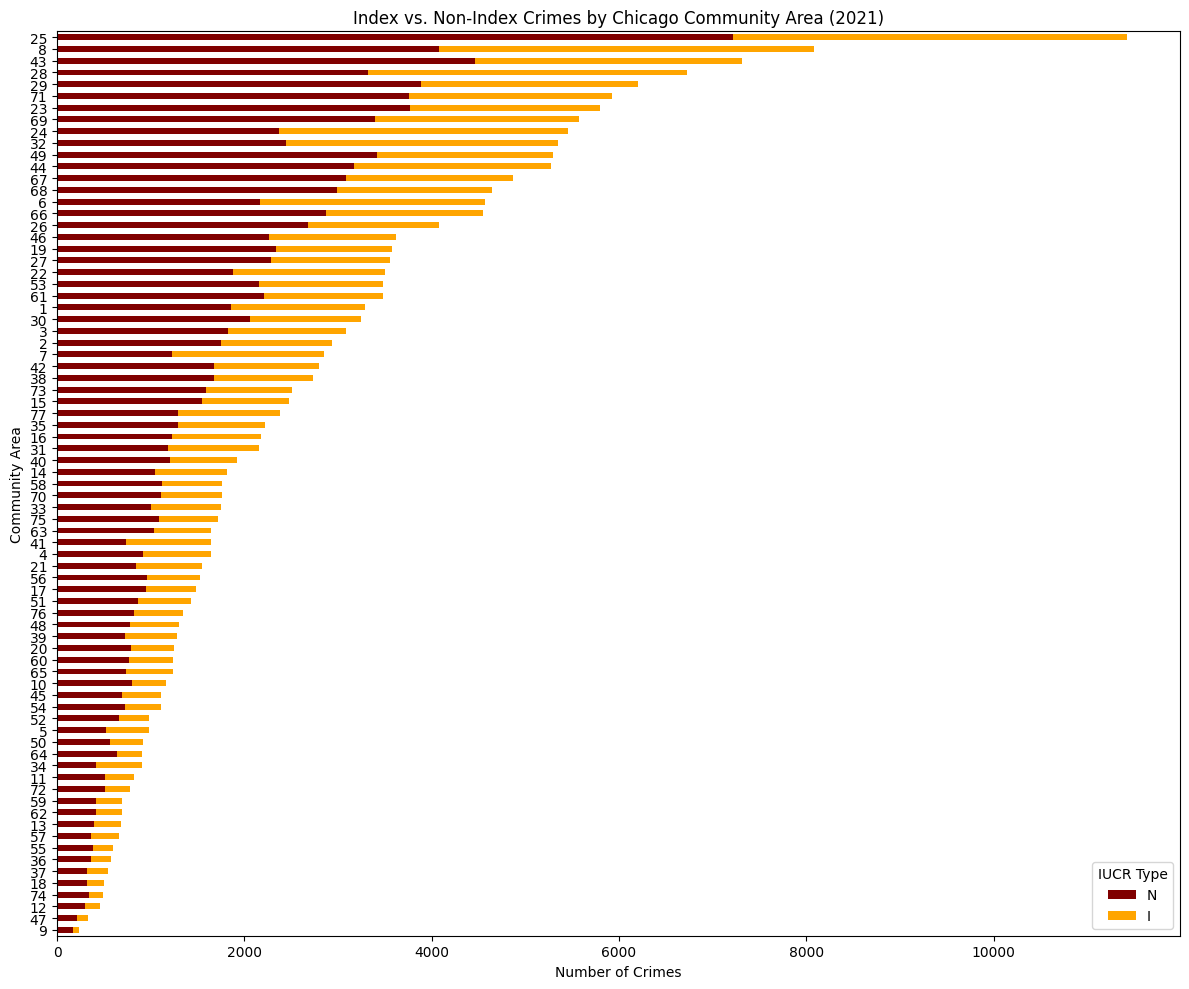

In [10]:
'''
About Code Chunk: This chunk does a very raw comparison of Index and Non-Index crimes in Chicago by community area - not really interpretable
but add foundation of the need of spatial lit review for crime analysis to get a normalized count for the community areas
'''

# Group by community_area and iucr_type, then count
crime_counts_by_area_type = chicago_crime_df_2021_cleaned.groupby(['community_area', 'iucr_type']).size().unstack(fill_value=0)

crime_counts_by_area_type['Total'] = crime_counts_by_area_type['I'] + crime_counts_by_area_type['N']
crime_counts_by_area_type = crime_counts_by_area_type.sort_values('Total', ascending=True).drop(columns=['Total'])

# Plotting a stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 10))
crime_counts_by_area_type[['N', 'I']].plot(kind='barh', stacked=True, ax=ax, color={'N': 'maroon', 'I': 'orange'})

ax.set_title('Raw Count Index vs. Non-Index Crimes by Chicago Community Area Comparison (2021)')
ax.set_xlabel('Number of Crimes')
ax.set_ylabel('Community Area')
ax.legend(title='IUCR Type')
plt.tight_layout()
plt.show()

In [52]:
'''
About Code Chunk: This chunk performs a spatial join. The intention here is to associate each crime incident (point) with the community area (polygon) it falls within.

'''
url = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=100"
# initial cleaning
resp = requests.get(url, timeout=30)
resp.raise_for_status()

community_areas = gpd.read_file(io.BytesIO(resp.content))

community_areas["area_numbe"] = community_areas["area_numbe"].astype(int)
community_areas = community_areas.rename(
    columns={"area_numbe": "area_num", "community": "name"}
)

community_areas = community_areas.to_crs(epsg=26971)

print(community_areas.shape)

# Convert chicago_crime_df_2021 to a GeoDataFrame
chicago_crime_df_2021_gdf = gpd.GeoDataFrame(
    chicago_crime_df_2021_cleaned,
    geometry=gpd.points_from_xy(chicago_crime_df_2021_cleaned["longitude"], chicago_crime_df_2021_cleaned["latitude"]),
    crs="EPSG:4326" # WGS84 - common lat/lon CRS
)

# Reproject chicago_crime_df_2021_gdf to match community_areas CRS
chicago_crime_df_2021_gdf = chicago_crime_df_2021_gdf.to_crs(epsg=26971)

# Perform a spatial join using 'within' predicate.
crimes_in_community_areas_2021 = gpd.sjoin(chicago_crime_df_2021_gdf, community_areas, how="inner", predicate="within")

display(crimes_in_community_areas_2021.head())




(77, 6)


,name,shape_area,area_num_1,area_num,shape_len,geometry
0,ROGERS PARK,51259902.4506,1,1,34052.3975757,"MULTIPOLYGON (((356237.576 592121.821, 356139...."
1,WEST RIDGE,98429094.8621,2,2,43020.6894583,"MULTIPOLYGON (((353726.032 594470.382, 353727...."
2,UPTOWN,65095642.7289,3,3,46972.7945549,"MULTIPOLYGON (((357397.618 587314.391, 357151...."
3,LINCOLN SQUARE,71352328.2399,4,4,36624.6030848,"MULTIPOLYGON (((354611.686 589658.442, 354612...."
4,NORTH CENTER,57054167.85,5,5,31391.6697542,"MULTIPOLYGON (((354735.595 584798.593, 354731...."
...,...,...,...,...,...,...
72,WASHINGTON HEIGHTS,79635752.8769,73,73,42222.598163,"MULTIPOLYGON (((358206.477 562223.393, 358212...."
73,MOUNT GREENWOOD,75584290.0209,74,74,48665.1305392,"MULTIPOLYGON (((353005.519 559771.882, 353008...."
74,MORGAN PARK,91877340.6988,75,75,46396.419362,"MULTIPOLYGON (((357545.1 557356.319, 357516.75..."
75,OHARE,371835607.687,76,76,173625.98466,"MULTIPOLYGON (((341164.11 590710.994, 341164.2..."


# **2. 311 Dataset**

In [12]:

'''
About Code Chunk: This code does the large query ingestion for the 2021 Chicago 311 Data filtering based on a select
group of 311 service request codes that are related to perceptions of safety
'''

# https://data.cityofchicago.org/resource/v6vf-nfxy.json

# Extract the dataset ID from the URL
three_one_one_dataset_id = "v6vf-nfxy"

# Define the year for which we want to retrieve data
year_to_query_311 = 2021

# Set a limit for each API call (max limit is usually 50000 by Socrata)
limit_311 = 50000

# List to store all fetched results
all_results_311 = []

'''
I specifically chose the codes that had to do with common safety indicators as seen in the broken windows theory.
Notably, I avoided using codes regarding animals or trash/sanitation and focused on the variables that physcolgically
has been connected to creating an environment conducive for crime or perception of safety
'''

# Dictionary to specify desired SR_SHORT_CODEs.
# codes definitions found in this dataset:
# https://data.cityofchicago.org/Service-Requests/311-Service-Requests-Request-Types/dgc7-2pdf/about_data

crimerelated_sr_short_codes_311 = {"BBK":"Vacant/Abandoned Building Complaint",
                                   "SCT": "Clean Vacant Lot Request",
                                   "SKA":"Abandoned Vehicle Complaint",
                                   "GRAF":"Graffiti Removal Request",
                                   "SFD":"Street Light Out Complaint",
                                   "SFC": "Viaduct Light Out Complaint",
                                   "SFA": "Alley Light Out Complaint"}

print(f"Fetching 311 data for {year_to_query_311} month by month...")

# Iterate through each month of the year
for month in range(1, 13):
    # Define the start and end dates for the current month
    month_start = f'{year_to_query_311}-{month:02d}-01T00:00:00.000'
    # Get the last day of the month
    if month == 12:
        month_end = f'{year_to_query_311}-12-31T23:59:59.999'
    else:
        next_month_start = f'{year_to_query_311}-{month+1:02d}-01T00:00:00.000'
        month_end = (pd.to_datetime(next_month_start) - pd.Timedelta(seconds=1)).strftime('%Y-%m-%dT%H:%M:%S.000')

    # Construct the $where clause for the current month
    where_clause_311_month = f"created_date between '{month_start}' and '{month_end}'"

    # Add SR_SHORT_CODE filter if crimerelated_sr_short_codes_311 is not empty

    if crimerelated_sr_short_codes_311:
        codes_str = ','.join([f"'{code}'" for code in list(crimerelated_sr_short_codes_311.keys())])
        where_clause_311_month += f" AND sr_short_code IN ({codes_str})"

    offset_311 = 0
    monthly_results = []
    print(f"  Fetching data for {year_to_query_311}-{month:02d}...")

    while True:
        # Fetch data with offset and limit for the current month
        results_311 = client.get(
            three_one_one_dataset_id,
            where=where_clause_311_month,
            limit=limit_311,
            offset=offset_311
        )

        if not results_311:
            # No more data to fetch for this month, break the loop
            break

        monthly_results.extend(results_311)
        offset_311 += limit_311
        # print(f"    Fetched {len(monthly_results)} records for {year_to_query_311}-{month:02d} so far...")

    print(f"  Finished fetching {len(monthly_results)} records for {year_to_query_311}-{month:02d}.")
    all_results_311.extend(monthly_results)

print(f"\nFinished fetching all 311 data for {year_to_query_311}. Total records: {len(all_results_311)}")

# Convert to pandas DataFrame
chicago_311_df_2021 = pd.DataFrame.from_records(all_results_311)

# Convert 'created_date' column to datetime objects
chicago_311_df_2021['created_date'] = pd.to_datetime(chicago_311_df_2021['created_date'])

# Display the head of the DataFrame and some info
print("\nDataFrame Head:")
display(chicago_311_df_2021.head())
print("\nDataFrame Info:")
chicago_311_df_2021.info()

Fetching 311 data for 2021 month by month...
  Fetching data for 2021-01...
  Finished fetching 14485 records for 2021-01.
  Fetching data for 2021-02...
  Finished fetching 12009 records for 2021-02.
  Fetching data for 2021-03...
  Finished fetching 22087 records for 2021-03.
  Fetching data for 2021-04...
  Finished fetching 19079 records for 2021-04.
  Fetching data for 2021-05...
  Finished fetching 17602 records for 2021-05.
  Fetching data for 2021-06...
  Finished fetching 19654 records for 2021-06.
  Fetching data for 2021-07...
  Finished fetching 19083 records for 2021-07.
  Fetching data for 2021-08...
  Finished fetching 20244 records for 2021-08.
  Fetching data for 2021-09...
  Finished fetching 16704 records for 2021-09.
  Fetching data for 2021-10...
  Finished fetching 16362 records for 2021-10.
  Fetching data for 2021-11...
  Finished fetching 15366 records for 2021-11.
  Fetching data for 2021-12...
  Finished fetching 13719 records for 2021-12.

Finished fetching 

,sr_number,sr_type,sr_short_code,owner_department,status,origin,created_date,last_modified_date,closed_date,street_address,...,created_month,x_coordinate,y_coordinate,latitude,longitude,location,created_department,city,state,electrical_district
0,SR21-00139428,Graffiti Removal Request,GRAF,Streets and Sanitation,Completed,Internet,2021-01-25 20:33:30,2021-01-26T10:12:32.000,2021-01-26T10:12:32.000,2 E 102ND ST,...,1,1178085.449301,1837354.992818,41.70902114585629,-87.62344491744882,"{'latitude': '41.70902114585629', 'longitude':...",NaN,NaN,NaN,NaN
1,SR21-00105967,Graffiti Removal Request,GRAF,Streets and Sanitation,Canceled,Internet,2021-01-19 16:28:43,2021-01-20T05:57:19.000,2021-01-20T05:57:19.000,5001 W 65TH ST,...,1,1144141.379197,1861013.759876,41.77464594588384,-87.74716308026598,"{'latitude': '41.77464594588384', 'longitude':...",NaN,NaN,NaN,NaN
2,SR21-00101647,Graffiti Removal Request,GRAF,Streets and Sanitation,Completed,Internet,2021-01-19 09:34:12,2021-01-21T13:52:31.000,2021-01-21T13:52:31.000,2021 W FULTON ST,...,1,1162708.541902,1901907.83671,41.88649637368789,-87.67795457487718,"{'latitude': '41.88649637368789', 'longitude':...",NaN,NaN,NaN,NaN
3,SR21-00164460,Street Light Out Complaint,SFD,CDOT - Department of Transportation,Completed,Internet,2021-01-29 22:05:22,2021-02-03T23:03:54.000,2021-02-03T23:03:54.000,8743 S WABASH AVE,...,1,1178334.351574,1846873.527923,41.7351356125718,-87.62224549039173,"{'latitude': '41.7351356125718', 'longitude': ...",NaN,NaN,NaN,NaN
4,SR21-00152105,Street Light Out Complaint,SFD,CDOT - Department of Transportation,Completed,Internet,2021-01-27 21:24:57,2021-02-03T23:03:54.000,2021-02-03T23:03:54.000,8743 S WABASH AVE,...,1,1178334.351574,1846873.527923,41.7351356125718,-87.62224549039173,"{'latitude': '41.7351356125718', 'longitude': ...",NaN,NaN,NaN,NaN



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206394 entries, 0 to 206393
Data columns (total 37 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sr_number            206394 non-null  object        
 1   sr_type              206394 non-null  object        
 2   sr_short_code        206394 non-null  object        
 3   owner_department     206394 non-null  object        
 4   status               206394 non-null  object        
 5   origin               206394 non-null  object        
 6   created_date         206394 non-null  datetime64[ns]
 7   last_modified_date   206394 non-null  object        
 8   closed_date          206358 non-null  object        
 9   street_address       205650 non-null  object        
 10  zip_code             205557 non-null  object        
 11  street_number        205645 non-null  object        
 12  street_direction     205640 non-null  object        
 1

In [13]:
# @title
'''
About Code Chunk: This code filtered the 311 data for only the needed columns for the analysis

'''
# only keep specific columns names
columns_needed = ["sr_short_code", "duplicate", "legacy_record", "created_date","community_area", "origin", "latitude", "longitude"]
chicago_311_df_2021 = chicago_311_df_2021[columns_needed]
chicago_311_df_2021

,sr_short_code,duplicate,legacy_record,created_date,community_area,origin,latitude,longitude
0,GRAF,True,False,2021-01-25 20:33:30,49,Internet,41.70902114585629,-87.62344491744882
1,GRAF,False,False,2021-01-19 16:28:43,NaN,Internet,41.77464594588384,-87.74716308026598
2,GRAF,True,False,2021-01-19 09:34:12,28,Internet,41.88649637368789,-87.67795457487718
3,SFD,True,False,2021-01-29 22:05:22,44,Internet,41.7351356125718,-87.62224549039173
4,SFD,True,False,2021-01-27 21:24:57,44,Internet,41.7351356125718,-87.62224549039173
...,...,...,...,...,...,...,...,...
206389,SKA,False,False,2021-12-31 15:40:46,62,Mobile Device,41.8023724240438,-87.714545219896
206390,SKA,False,False,2021-12-31 21:04:13,70,Phone Call,41.735212108623145,-87.73937837852573
206391,GRAF,False,False,2021-12-31 16:32:05,31,Phone Call,41.857151897459694,-87.64078094402333
206392,SFD,False,False,2021-12-31 11:12:17,37,Phone Call,41.80351791285569,-87.63351616691776


# **3. Spatial Mapping and Comparison - Community Area Choropleths**

*    Map A — Index Crime by Community Area - normalized to population of community (per 1000)
*    Map B — Non-Index Crime by Community Area - normalized to population of community (per 1000)


,name,shape_area,area_num_1,area_num,shape_len,geometry,Community Area,population,community_area,I,N,index_crime_rate_per_1000,nonindex_crime_rate_per_1000
0,ROGERS PARK,51259902.4506,1,1,34052.3975757,"MULTIPOLYGON (((356237.576 592121.821, 356139....",ROGERS PARK,53169,1,1367,1833,25.710470,34.474976
1,WEST RIDGE,98429094.8621,2,2,43020.6894583,"MULTIPOLYGON (((353726.032 594470.382, 353727....",WEST RIDGE,79220,2,1180,1740,14.895228,21.964150
2,UPTOWN,65095642.7289,3,3,46972.7945549,"MULTIPOLYGON (((357397.618 587314.391, 357151....",UPTOWN,52674,3,1268,1822,24.072597,34.590120
3,LINCOLN SQUARE,71352328.2399,4,4,36624.6030848,"MULTIPOLYGON (((354611.686 589658.442, 354612....",LINCOLN SQUARE,42180,4,723,920,17.140825,21.811285
4,NORTH CENTER,57054167.85,5,5,31391.6697542,"MULTIPOLYGON (((354735.595 584798.593, 354731....",NORTH CENTER,35782,5,456,525,12.743838,14.672182


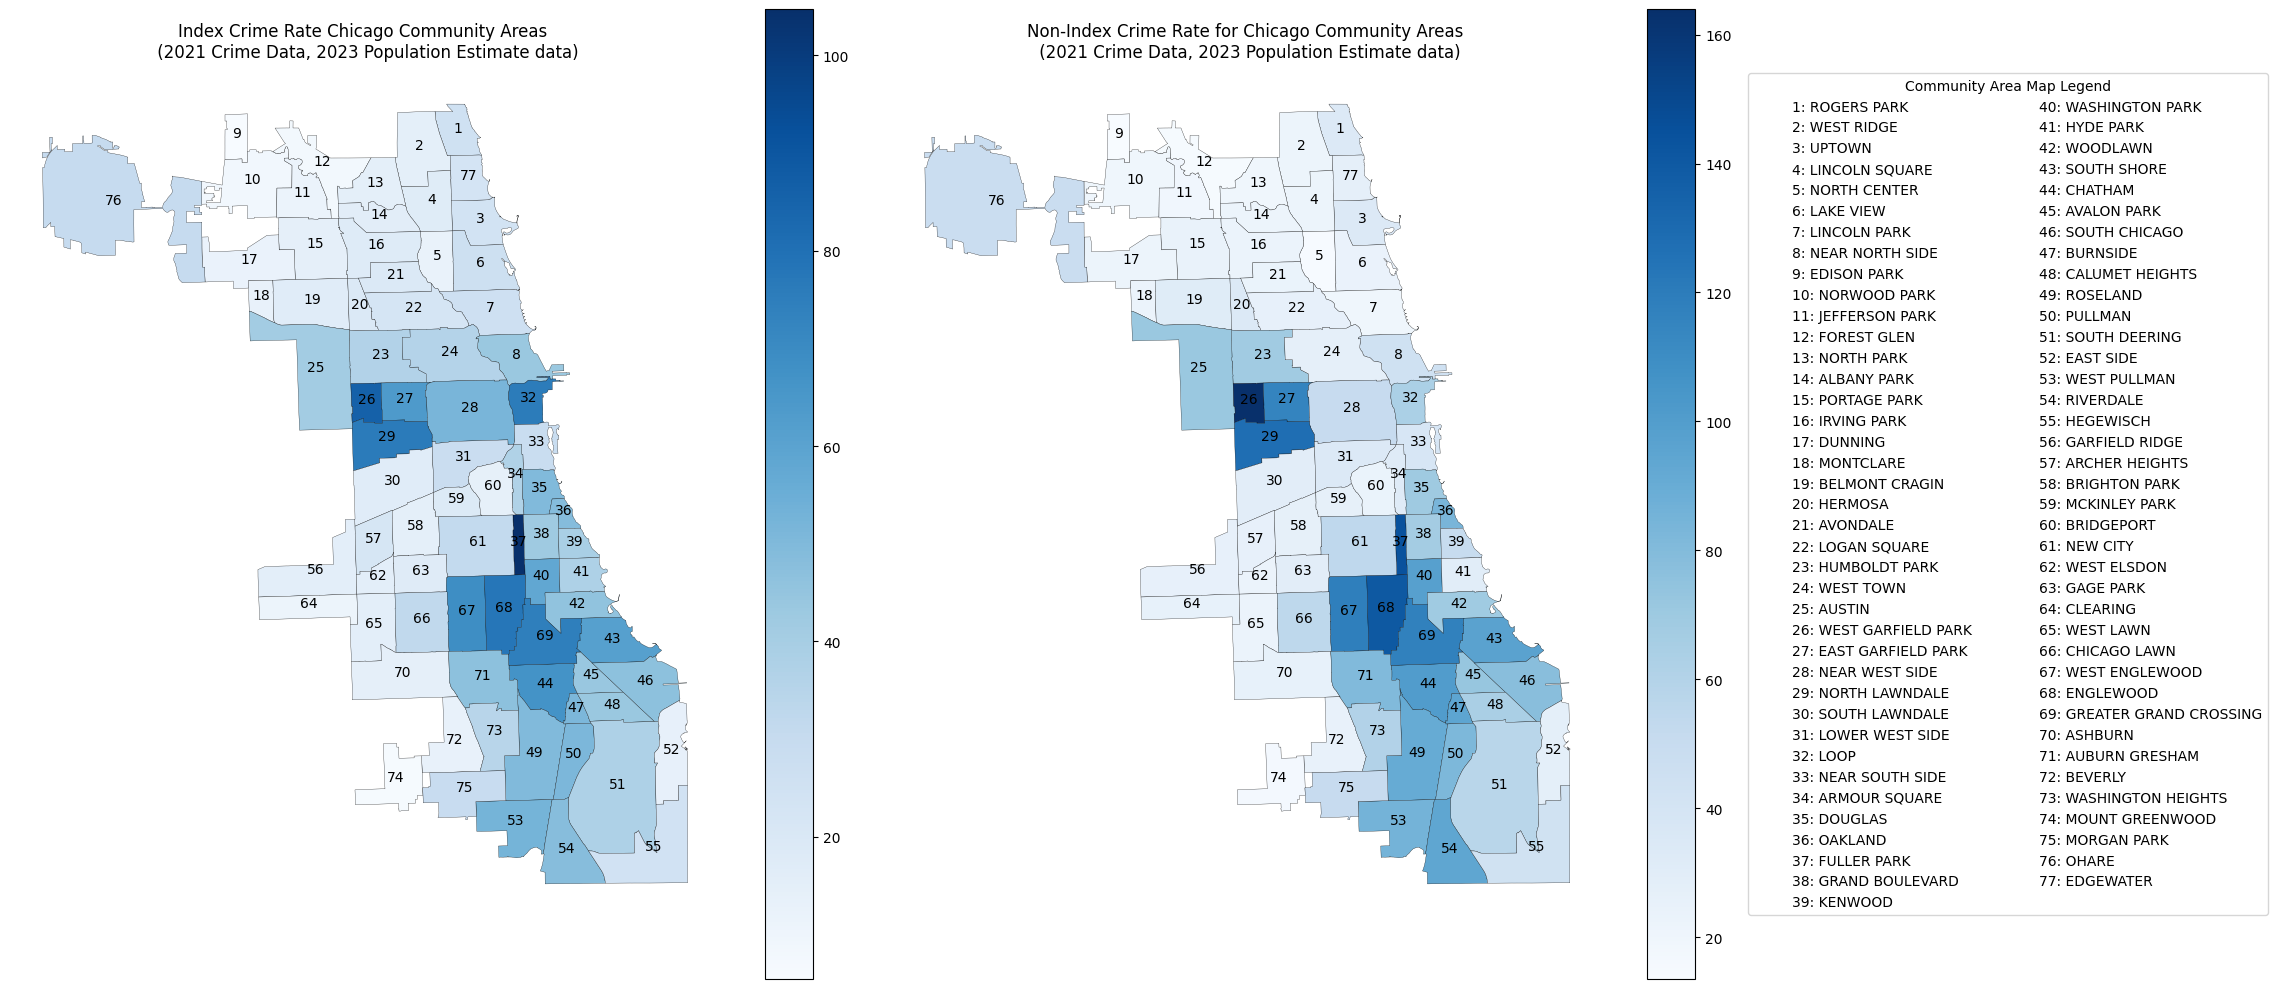

In [102]:

'''
About Code Chunk: This code builds a Choropleth map for Index and Non-Index Crimes in Chicago by community area.
'''

# Group by community area and count the number of index crimes
# The result is a DataFrame with 'community_area' as index and 'I' (Index) and 'N' (Non-Index) crime counts as columns.
crime_counts_by_area_type = crimes_in_community_areas_2021.groupby(['community_area', 'iucr_type']).size().unstack(fill_value=0)
crime_counts_by_area_type = crime_counts_by_area_type.fillna(0)

# Normalization by population
# using loaded csv
# https://data.cityofchicago.org/Community-Economic-Development/ACS-5-Year-Data-by-Community-Area/t68z-cikk/about_data
acs_populations = pd.read_csv("/ACS_5_Year_Data_by_Community_Area_20260528.csv")

# Clean column names by stripping whitespace
acs_populations.columns = acs_populations.columns.str.strip()

# Convert 'Total Population' to numeric, handling commas
acs_populations["Total Population"] = (
    acs_populations["Total Population"]
    .astype(str)
    .str.replace(",", "")
    .astype(int)
)

#    This links the geographic data with the population data using the community area names.
community_areas_with_population = community_areas.merge(
    acs_populations[['Community Area', 'Total Population']],
    left_on='name',
    right_on='Community Area',
    how='left'
)
# Rename the 'Total Population' column to 'population' for consistency
community_areas_with_population = community_areas_with_population.rename(columns={'Total Population': 'population'})

community_areas_with_population['population'] = community_areas_with_population['population'].fillna(0).astype(int)
crime_counts_reset = crime_counts_by_area_type.reset_index()
crime_counts_reset['community_area'] = crime_counts_reset['community_area'].astype(int)

# Merge the combined geographic and population data with the crime counts
community_areas_with_crime_and_population = community_areas_with_population.merge(
    crime_counts_reset,
    left_on='area_num', # Numeric ID from the geographic data
    right_on='community_area', # Numeric ID from the crime counts
    how='left'
)

community_areas_with_crime_and_population['I'] = community_areas_with_crime_and_population['I'].fillna(0)
community_areas_with_crime_and_population['N'] = community_areas_with_crime_and_population['N'].fillna(0)

# Calculate rates per 1000 people, handling division by zero by replacing 0 population with NaN
population_for_division = community_areas_with_crime_and_population['population'].replace(0, np.nan)

community_areas_with_crime_and_population['index_crime_rate_per_1000'] = \
    (community_areas_with_crime_and_population['I'] / population_for_division) * 1000

community_areas_with_crime_and_population['nonindex_crime_rate_per_1000'] = \
    (community_areas_with_crime_and_population['N'] / population_for_division) * 1000

community_areas_with_crime_and_population['index_crime_rate_per_1000'] = \
    community_areas_with_crime_and_population['index_crime_rate_per_1000'].fillna(0)

community_areas_with_crime_and_population['nonindex_crime_rate_per_1000'] = \
    community_areas_with_crime_and_population['nonindex_crime_rate_per_1000'].fillna(0)

display(community_areas_with_crime_and_population.head())


fig, axes = plt.subplots(1, 2, figsize=(18, 10))

community_areas_with_crime_and_population.plot(
    column="index_crime_rate_per_1000",
    cmap="Blues",
    legend=True,
    ax=axes[0],
    edgecolor="black",
    linewidth=0.2
)
# adding community area number labels
for idx, row in community_areas_with_crime_and_population.iterrows():
    axes[0].annotate(
        text=row["area_num"],
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center"
    )

axes[0].set_title("Index Crime Rate Chicago Community Areas \n (2021 Crime Data, 2023 Population Estimate data)")
axes[0].axis("off")

# adding community area number labels
community_areas_with_crime_and_population.plot(
    column="nonindex_crime_rate_per_1000",
    cmap="Blues",
    legend=True,
    ax=axes[1],
    edgecolor="black",
    linewidth=0.2
)
for idx, row in community_areas_with_crime_and_population.iterrows():
    axes[1].annotate(
        text=row["area_num"],
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center"
    )

axes[1].set_title("Non-Index Crime Rate for Chicago Community Areas \n (2021 Crime Data, 2023 Population Estimate data)")
axes[1].axis("off")
###############################################################################
# adding community number legend
legend_elements = []
for idx, row in community_areas_with_crime_and_population.iterrows():
    num = row['area_num']
    name = row['name']

    handle = plt.Line2D([0], [0],color='w', markerfacecolor='gray',
                        markersize=10, label=f"{num}: {name}")
    legend_elements.append(handle)

fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.97, 0.5),
    title="Community Area Map Legend",
    ncol=2
)

plt.tight_layout()
plt.show()

## 3a. Discussion on Spatial Mapping and Comparison - Community Area Choropleths

As we can see from the two side by side choropleths from above, we can see most community areas in the South and North extremities follow similar rate patterns as far Index vs Non-Index. However towards the center area, we see some rate varaiation, especially in community area number 32, the "Loop" area, where they have a seemingly higher rate of Index Crimes than the Non-Index Crimes. Contrastly, number 26, "West Garfield Park" sees a high rate on Non-Index crimes than Index crimes for its community area population.



# **4. Point Density Maps/KDE Maps**
Now we are going to take another method of comparison, which is the Point Density/kde Maps in which we will have three maps Index Crimes, Non-Index Crimes and 311 Disorder Reuqests (related to percieved safety) to see visually is hotspot overlap and if other patterns appear that were missing in the choropleth comparison, if 311 patterns are more diffused, and to see is non-index crimes resemble disorder complaint pattens.

## 4a. Density Maps Just for Index versus Non-Index Crimes

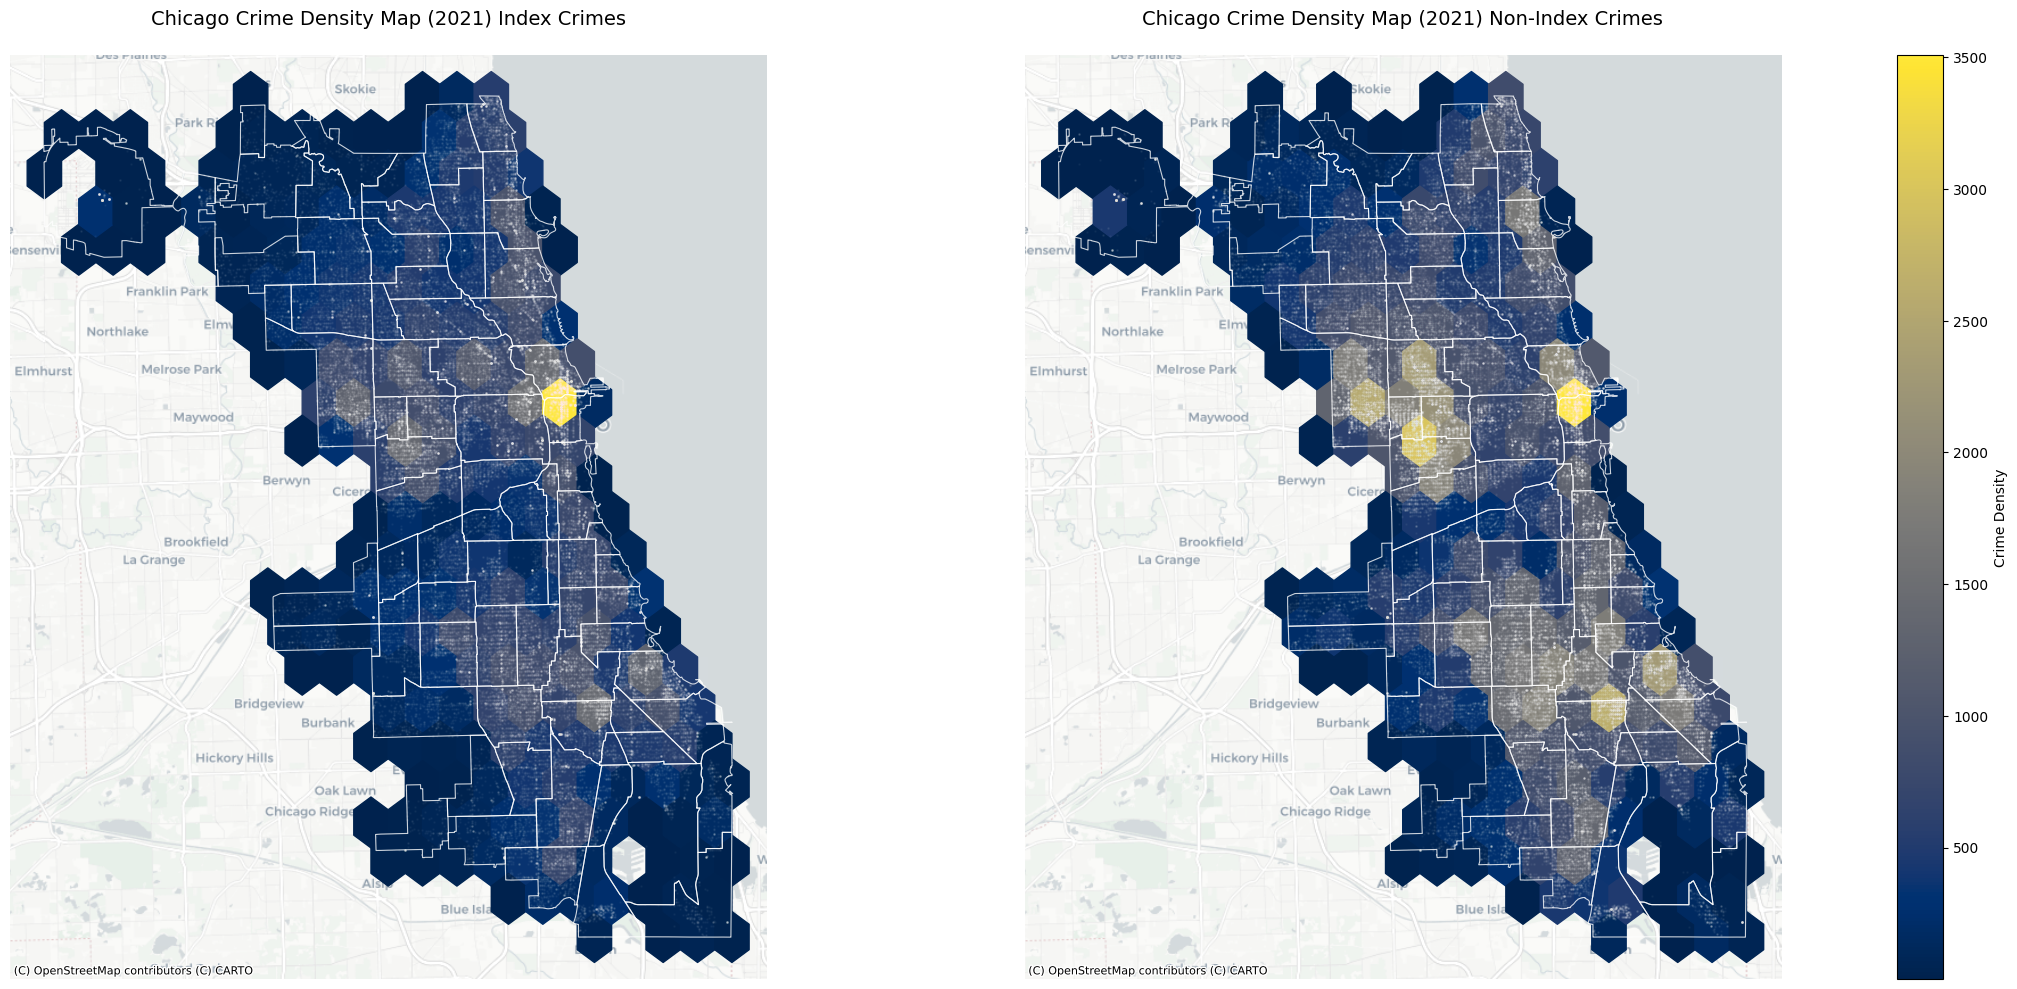

In [159]:
'''
About Code Chunk: This code builds a KDE maps for Index and Non-Index Crimes in Chicago.
'''

crime_points = chicago_crime_df_2021_gdf.to_crs(epsg=3857)
community_areas_3857 = community_areas.to_crs(epsg=3857)

fig, ax = plt.subplots(1,2, figsize = (30,12))
# NON INDEX CRIMES
# Layer 1 - density
density = ax[1].hexbin(
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "N"].geometry.x,
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "N"].geometry.y,
    gridsize =20,
    cmap = "cividis",
    mincnt =1
)
# Layer 2- basemap
cx.add_basemap(ax[1], source = cx.providers.CartoDB.Positron)

# Layer 3: community area outline
# Plot the reprojected community_areas_3857 for correct alignment
community_areas_3857.boundary.plot(
    ax=ax[1],
    linewidth=0.8,
    color="white",
    alpha=0.8
)
community_areas_3857.plot(
    ax=ax[1],
    facecolor="none",
    edgecolor="none"
)
# Layer 4: Raw points
crime_points[crime_points["iucr_type"] == "N"].plot(ax=ax[1], markersize =1, color = "white", alpha = .03)

ax[1].set_title("Chicago Crime Density Map (2021) Non-Index Crimes\n", size=14)
ax[1].set_axis_off()
######################################################
# INDEX CRIMES
# NON INDEX CRIMES
# Layer 1 - density
density = ax[0].hexbin(
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "I"].geometry.x,
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "I"].geometry.y,
    gridsize =20,
    cmap = "cividis",
    mincnt =1
)
# Layer 2- basemap
cx.add_basemap(ax[0], source = cx.providers.CartoDB.Positron)

# Layer 3: community area outline
# Plot the reprojected community_areas_3857 for correct alignment
community_areas_3857.boundary.plot(
    ax=ax[0],
    linewidth=0.8,
    color="white",
    alpha=0.8
)
community_areas_3857.plot(
    ax=ax[0],
    facecolor="none",
    edgecolor="none"
)
# Layer 4: Raw points
crime_points[crime_points["iucr_type"] == "I"].plot(ax=ax[0], markersize =1, color = "white", alpha = .03)


ax[0].set_title("Chicago Crime Density Map (2021) Index Crimes\n", size =14)
ax[0].set_axis_off()

plt.colorbar(density, ax=ax, label="Crime Density")
plt.show()

## 4b. Adding 311 Density In Comparison to the Index and Non Index Crimes

This figure visualizes spatial distribution of Index Crimes, Non-Index Crimes, and 311 service requests in Chicago (2021). Each panel shows kernel-style hexagonal density estimates overlaid on a basemap with community area boundaries. White points represent individual reported incidents (crime events or 311 requests), displayed with low opacity to preserve visibility of underlying spatial density patterns. Panel A displays Index Crimes (violent and property offenses), Panel B shows Non-Index Crimes (quality-of-life and disorder-related offenses), and Panel C visualizes 311 service requests as a proxy for perceived neighborhood disorder.

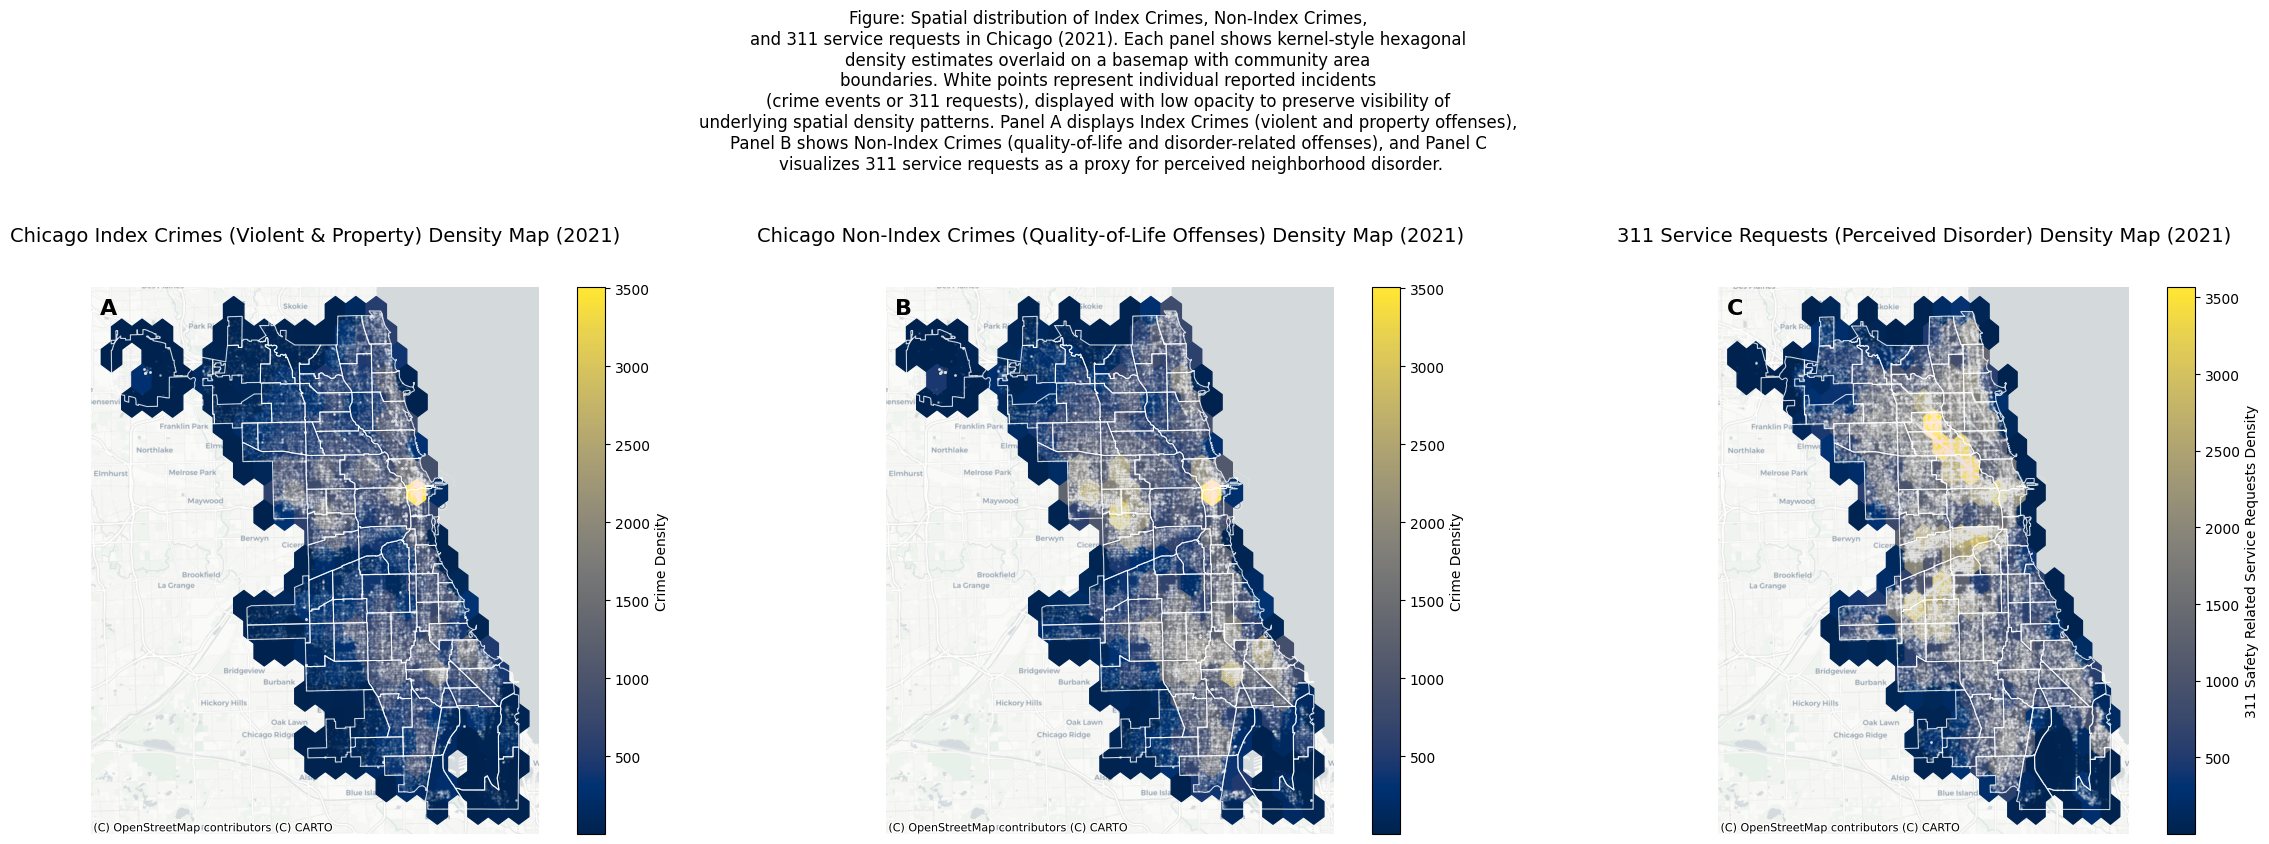

In [178]:
'''
About Code Chunk: This code builds on the last chunk of density maps of Index and Non-Index Crimes in Chicago and compared the density of 311 incidents.
'''

crime_points = chicago_crime_df_2021_gdf.to_crs(epsg=3857)
community_areas_3857 = community_areas.to_crs(epsg=3857)

fig, ax = plt.subplots(1,3, figsize = (24,8))
# NON INDEX CRIMES

# Layer 1 - density
density = ax[1].hexbin(
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "N"].geometry.x,
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "N"].geometry.y,
    gridsize =20,
    cmap = "cividis",
    mincnt =1
)
# Layer 2- basemap
cx.add_basemap(ax[1], source = cx.providers.CartoDB.Positron)

# Layer 3: community area outline
# Plot the reprojected community_areas_3857 for correct alignment
community_areas_3857.boundary.plot(
    ax=ax[1],
    linewidth=0.8,
    color="white",
    alpha=0.8
)
community_areas_3857.plot(
    ax=ax[1],
    facecolor="none",
    edgecolor="none"
)
# Layer 4: Raw points
crime_points[crime_points["iucr_type"] == "N"].plot(ax=ax[1], markersize =1, color = "white", alpha = .03)

ax[1].set_title("Chicago Non-Index Crimes (Quality-of-Life Offenses) Density Map (2021)\n", size=14)
ax[1].set_axis_off()
######################################################
# INDEX CRIMES
# NON INDEX CRIMES

# Layer 1 - density
density = ax[0].hexbin(
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "I"].geometry.x,
    chicago_crime_df_2021_gdf[chicago_crime_df_2021_gdf["iucr_type"] == "I"].geometry.y,
    gridsize =20,
    cmap = "cividis",
    mincnt =1
)

# Layer 2- basemap
cx.add_basemap(ax[0], source = cx.providers.CartoDB.Positron)

# Layer 3: community area outline
# Plot the reprojected community_areas_3857 for correct alignment
community_areas_3857.boundary.plot(
    ax=ax[0],
    linewidth=0.8,
    color="white",
    alpha=0.8
)
community_areas_3857.plot(
    ax=ax[0],
    facecolor="none",
    edgecolor="none"
)
# Layer 4: Raw points
crime_points[crime_points["iucr_type"] == "I"].plot(ax=ax[0], markersize =1, color = "white", alpha = .03)


ax[0].set_title("Chicago Index Crimes (Violent & Property) Density Map (2021)\n", size =14)
ax[0].set_axis_off()

plt.colorbar(density, ax=ax[1], label="Crime Density")
plt.colorbar(density, ax=ax[0], label="Crime Density")
#######################################################
# 311 DATA

# Convert 311 data to GeoDataFrame and reproject
chicago_311_df_2021['latitude'] = pd.to_numeric(chicago_311_df_2021['latitude'], errors='coerce')
chicago_311_df_2021['longitude'] = pd.to_numeric(chicago_311_df_2021['longitude'], errors='coerce')
chicago_311_df_2021.dropna(subset=['latitude', 'longitude'], inplace=True)

chicago_311_gdf = gpd.GeoDataFrame(
    chicago_311_df_2021,
    geometry=gpd.points_from_xy(chicago_311_df_2021['longitude'], chicago_311_df_2021['latitude']),
    crs="EPSG:4326" # WGS84 - common lat/lon CRS
).to_crs(epsg=3857)


# Layer 2 - density
density = ax[2].hexbin(
    chicago_311_gdf.geometry.x,
    chicago_311_gdf.geometry.y,
    gridsize =20,
    cmap = "cividis",
    mincnt =1
)

# Layer 2- basemap
cx.add_basemap(ax[2], source = cx.providers.CartoDB.Positron)

# Layer 3: community area outline
# Plot the reprojected community_areas_3857 for correct alignment
community_areas_3857.boundary.plot(
    ax=ax[2],
    linewidth=0.8,
    color="white",
    alpha=0.8
)
community_areas_3857.plot(
    ax=ax[2],
    facecolor="none",
    edgecolor="none"
)
# Layer 4: Raw points
chicago_311_gdf.plot(ax=ax[2], markersize =1, color = "white", alpha = .03)

plt.colorbar(density, ax=ax[2], label="311 Safety Related Service Requests Density")

ax[2].set_title("311 Service Requests (Perceived Disorder) Density Map (2021)\n", size=14)
ax[2].set_axis_off()

ax[0].text(0.02, 0.95, "A", transform=ax[0].transAxes, fontsize=16, fontweight="bold")
ax[1].text(0.02, 0.95, "B", transform=ax[1].transAxes, fontsize=16, fontweight="bold")
ax[2].text(0.02, 0.95, "C", transform=ax[2].transAxes, fontsize=16, fontweight="bold")

fig.suptitle("Figure: Spatial distribution of Index Crimes, Non-Index Crimes, \nand 311 service requests in Chicago (2021). Each panel shows kernel-style hexagonal \ndensity estimates overlaid on a basemap with community area \nboundaries. White points represent individual reported incidents \n(crime events or 311 requests), displayed with low opacity to preserve visibility of \nunderlying spatial density patterns. Panel A displays Index Crimes (violent and property offenses), \nPanel B shows Non-Index Crimes (quality-of-life and disorder-related offenses), and Panel C \nvisualizes 311 service requests as a proxy for perceived neighborhood disorder.", y=1.05)
plt.tight_layout()
plt.show()

## **4c. An Analysis of the Above Comparative KDE Figues**

The 311 service request layer exhibits the most spatial diffusion and the widest distribution of localized hotspots across Chicago, suggesting that perceived disorder is more broadly distributed across the city than either index or non-index crime. Unlike the crime layers, which are more spatially concentrated in the central and south sides mostly, 311 requests reflect a combination of residential and community area reporting behavior, producing a denser and more continuous pattern of activity. However, despite this broader dispersion, there is still clear spatial convergence across all three maps, specifically in the central corridor and Near North Side. These areas consistently emerge as hotspots in index crimes, non-index crimes, and 311 requests, indicating a persistent overlap between serious crime, quality-of-life offenses, and perceived disorder, which contrasts widely with social phenomena that the South side is the area of high concentration of crimes and safety issues. This convergence suggests that certain neighborhoods function as multi-dimensional urban hotspots where both reported criminal activity and resident-perceived issues co-occur, thus reinforcing their visibility within the city's overall spatial narrative of safety and disorder. However, the divergence of the diffuse 311 patterns and the more concentrated patterns of the others highlights that perceived disorder is not always spatially aligned with recorded criminal activity, nor does it adhere strictly to community area bounds.

# **5. Correlation between the three datasets (Index, Non-Index, and 311)**



In [181]:
'''
About Code Chunk: This code coducts a Correlation between the three datasets (Index, Non-Index, and 311)

'''

# Aggregate 311 service requests by community area
chicago_311_gdf['community_area'] = pd.to_numeric(chicago_311_gdf['community_area'], errors='coerce')
chicago_311_gdf.dropna(subset=['community_area'], inplace=True)

three_one_one_counts_by_area = chicago_311_gdf.groupby('community_area').size().reset_index(name='311_request_count')

community_areas_with_all_data = community_areas_with_crime_and_population.merge(
    three_one_one_counts_by_area,
    left_on='area_num',
    right_on='community_area',
    how='left'
)

community_areas_with_all_data['311_request_count'] = community_areas_with_all_data['311_request_count'].fillna(0)

# normalizing 311 counts
community_areas_with_all_data['311_request_rate_per_1000'] = \
    (community_areas_with_all_data['311_request_count'] / community_areas_with_all_data['population'].replace(0, np.nan)) * 1000
community_areas_with_all_data['311_request_rate_per_1000'] = community_areas_with_all_data['311_request_rate_per_1000'].fillna(0)

# 4. correlation matrix
correlation_data = community_areas_with_all_data[[
    'index_crime_rate_per_1000',
    'nonindex_crime_rate_per_1000',
    '311_request_rate_per_1000'
]]


correlation_matrix = correlation_data.corr()

print("Correlation Matrix of Index Crime Rate, Non-Index Crime Rate, and 311 Request Rate per 1000 People:")
display(correlation_matrix)




Correlation Matrix of Index Crime Rate, Non-Index Crime Rate, and 311 Request Rate per 1000 People:


,index_crime_rate_per_1000,nonindex_crime_rate_per_1000,311_request_rate_per_1000
index_crime_rate_per_1000,1.000000,0.936357,0.194170
nonindex_crime_rate_per_1000,0.936357,1.000000,0.172092
311_request_rate_per_1000,0.194170,0.172092,1.000000


## 5a. An Analysis of the Correlation Matrix of Index Crime Rate, Non-Index Crime Rate, and 311 Request Rate per 1000 People

Lastly, looking at a correlation matrix of the three datasets at a normalized rate per 1000 per (based on 2023 population). There is a very high correlation between index and non-index crime, which aligns with the similar spatial diffusion patterns observed in the density maps. However, interestingly, both index and non-index crime have a relatively weak correlation with the 311 request rates that are specifically related to safety requests.



If 311 safety-related request as intrprested as a proxy for the perception of neighborhood disorder or safety concerns for the purposes of this project, these results suggest that perception of safety and disorder may not align closely with officially reported crime rates across Chchaog community areas. This indicated that residents' perception of neighborhood safety may be shaped by additional social or environmental factors beyond recorded criminal incidents alone (both index and non-index).



But, the weak correlation could also be the result of large outliers seen within the density maps, where there were barely are barely any hotspots that could bring the correlation towards zero. As a result, while the correlation analysis suggests divergence between perceived disorder and reported crime, the relationship is likely more spatially complex than a simple linear correlation can capture.

# **References**

Authority, I. C. J. I. (2017). ICJIA. Illinois Criminal Justice Information Authority. Retrieved May 28, 2026, from https://icjia.illinois.gov/

Illinois State Police. (n.d.). Illinois Uniform Crime Reporting Program: Monthly index crime form (ISP 2-423C). State of Illinois. https://isp.illinois.gov/StaticFiles/docs/CrimeReporting/2-423c.pdf

Malleson, N., Steenbeek, W., & Andresen, M. A. (2019). Identifying the appropriate spatial resolution for the analysis of crime patterns. PloS one, 14(6), e0218324. https://doi.org/10.1371/journal.pone.0218324


Social Disorganization Theory – Explaining Crime in Urban Neighborhoods | SozTheo. (2018, 2026). Retrieved May 28, 2026, from https://soztheo.com/theories-of-crime/space-surveillance/soziale-desorganisation-shaw-mckay/
